In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.decomposition import PCA

import joblib

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv(
    "C:\AI-Based Indian Grocery Segmentation using Clustering\data\GroceryDataset_EDA_Final.csv"
)

print("Shape:", df.shape)

df.head()

Shape: (1754, 15)


,Sub Category,Price,Discount,Rating,Title,Currency,Feature,Product Description,Price_num,Discount_num,Rating_num,Reviews_num,Title_Length,Feature_Length,Description_Length
0,Bakery & Desserts,$56.99,No Discount,Rated 4.3 out of 5 stars based on 265 reviews.,"David’s Cookies Mile High Peanut Butter Cake, ...",$,"""10"""" Peanut Butter Cake\nCertified Kosher OU-...",A cake the dessert epicure will die for!Our To...,56.99,0.0,4.3,265.0,67,58,764
1,Bakery & Desserts,$159.99,No Discount,Rated 5 out of 5 stars based on 1 reviews.,"The Cake Bake Shop 8"" Round Carrot Cake (16-22...",$,Spiced Carrot Cake with Cream Cheese Frosting ...,"Due to the perishable nature of this item, ord...",159.99,0.0,5.0,1.0,56,161,1343
2,Bakery & Desserts,$44.99,No Discount,Rated 4.1 out of 5 stars based on 441 reviews.,"St Michel Madeleine, Classic French Sponge Cak...",$,100 count\nIndividually wrapped\nMade in and I...,Moist and buttery sponge cakes with the tradit...,44.99,0.0,4.1,441.0,59,99,1173
3,Bakery & Desserts,$39.99,No Discount,Rated 4.7 out of 5 stars based on 9459 reviews.,"David's Cookies Butter Pecan Meltaways 32 oz, ...",$,Butter Pecan Meltaways\n32 oz 2-Pack\nNo Prese...,These delectable butter pecan meltaways are th...,39.99,0.0,4.7,9459.0,52,88,629
4,Bakery & Desserts,$59.99,No Discount,Rated 4.5 out of 5 stars based on 758 reviews.,"David’s Cookies Premier Chocolate Cake, 7.2 lb...",$,"""10"" Four Layer Chocolate Cake\nCertified Kosh...",A cake the dessert epicure will die for!To the...,59.99,0.0,4.5,758.0,59,62,814


In [4]:
features = [
    "Price_num",
    "Discount_num",
    "Rating_num",
    "Reviews_num",
    "Title_Length",
    "Feature_Length",
    "Description_Length"
]

X = df[features].copy()

X.head()

,Price_num,Discount_num,Rating_num,Reviews_num,Title_Length,Feature_Length,Description_Length
0,56.99,0.0,4.3,265.0,67,58,764
1,159.99,0.0,5.0,1.0,56,161,1343
2,44.99,0.0,4.1,441.0,59,99,1173
3,39.99,0.0,4.7,9459.0,52,88,629
4,59.99,0.0,4.5,758.0,59,62,814


In [5]:
print("Shape:", X.shape)

print("\nMissing:")
print(X.isnull().sum())

Shape: (1754, 7)

Missing:
Price_num             0
Discount_num          0
Rating_num            0
Reviews_num           0
Title_Length          0
Feature_Length        0
Description_Length    0
dtype: int64


In [6]:
X_train, X_test = train_test_split(
    X,
    test_size=0.20,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (1403, 7)
Test : (351, 7)


In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

find best k


In [8]:
inertia = []

K_range = range(2, 11)

for k in K_range:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_train_scaled)

    inertia.append(model.inertia_)

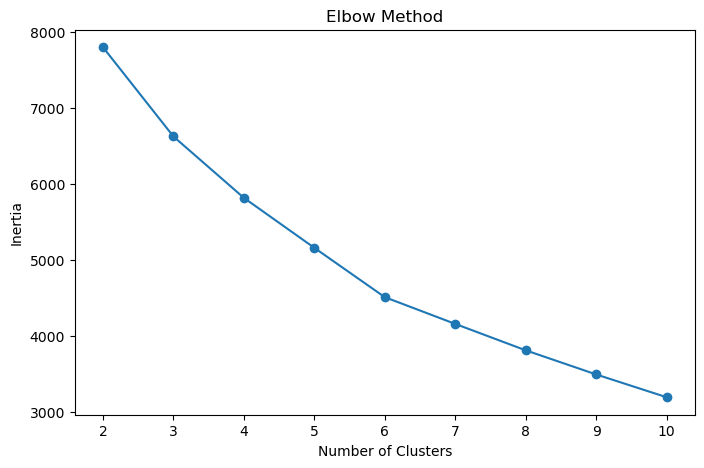

In [9]:
plt.figure(figsize=(8,5))

plt.plot(
    K_range,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [18]:
silhouette_scores = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_train_scaled)

    score = silhouette_score(
        X_train_scaled,
        labels
    )

    silhouette_scores.append(score)

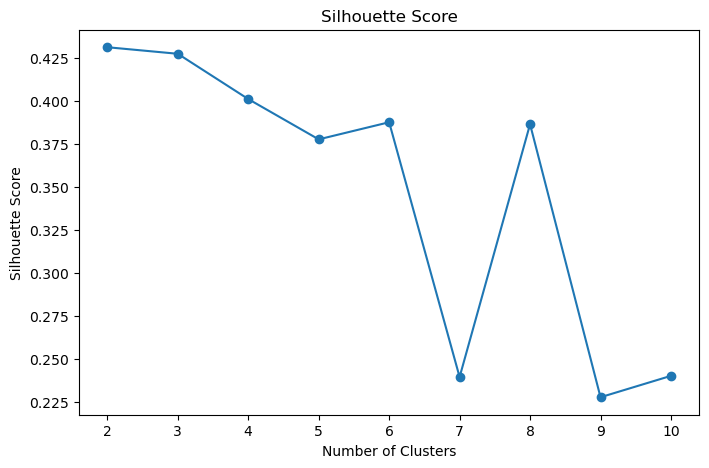

In [19]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")

plt.show()

In [20]:
best_k = range(2, 11)[
    np.argmax(silhouette_scores)
]

print("Best K:", best_k)
print(
    "Best Silhouette:",
    max(silhouette_scores)
)

Best K: 2
Best Silhouette: 0.43136945412421734


In [21]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

train_clusters = kmeans.fit_predict(
    X_train_scaled
)

In [22]:
test_clusters = kmeans.predict(
    X_test_scaled
)

print(test_clusters[:20])

[0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 1 0 0]


In [23]:
silhouette = silhouette_score(
    X_train_scaled,
    train_clusters
)

print("Silhouette Score:", round(silhouette, 4))

Silhouette Score: 0.4314


In [24]:
db_score = davies_bouldin_score(
    X_train_scaled,
    train_clusters
)

print(
    "Davies-Bouldin Score:",
    round(db_score, 4)
)

Davies-Bouldin Score: 1.6301


In [25]:
cluster_counts = (
    pd.Series(train_clusters)
    .value_counts()
    .sort_index()
)

print(cluster_counts)

0    1028
1     375
Name: count, dtype: int64


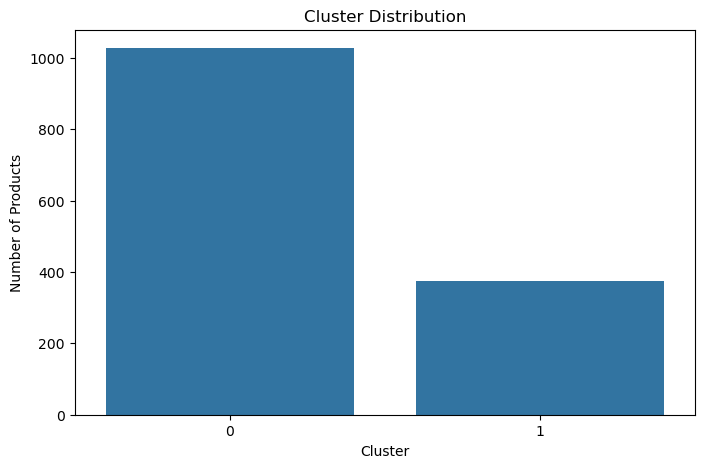

In [26]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.xlabel("Cluster")
plt.ylabel("Number of Products")
plt.title("Cluster Distribution")

plt.show()

In [27]:
train_data = X_train.copy()

train_data["Cluster"] = train_clusters

cluster_profile = (
    train_data
    .groupby("Cluster")
    .mean()
    .round(2)
)

cluster_profile

,Price_num,Discount_num,Rating_num,Reviews_num,Title_Length,Feature_Length,Description_Length
Cluster,,,,,,,
0,26.03,0.36,4.50,297.17,54.93,84.01,335.39
1,145.52,2.16,4.27,663.65,65.94,163.76,1490.67


In [28]:
train_products = df.loc[X_train.index].copy()

train_products["Cluster"] = train_clusters

In [29]:
train_products[
    [
        "Title",
        "Sub Category",
        "Price_num",
        "Discount_num",
        "Rating_num",
        "Reviews_num",
        "Cluster"
    ]
].head(20)

,Title,Sub Category,Price_num,Discount_num,Rating_num,Reviews_num,Cluster
199,"Bisquick, Pancake & Baking Mix, 96 oz",Breakfast,10.99,0.0,4.5,208.0,0
1376,"Eco Raj 6-inch Compostable Bagasse Plate, 1000...",Paper & Plastic Products,52.99,0.0,3.7,6.0,0
798,"Sharpie Fine Point Permanent Marker, 25-count",Household,16.99,0.0,4.5,208.0,0
1234,"Hidden Valley, Original Ranch Dressing, 40 fl ...",Pantry & Dry Goods,14.99,0.0,4.5,208.0,0
1576,No Sugar Keto Bar Chocolate Chip Cookie Dough ...,Snacks,42.99,0.0,3.7,82.0,0
1348,"Dixie Ultra 8-1/2"" Paper Plate, 240-count",Paper & Plastic Products,22.99,0.0,4.5,208.0,0
1280,Nielsen-Massey Madagascar Bourbon Pure Vanilla...,Pantry & Dry Goods,49.99,0.0,4.8,880.0,0
669,The Fruit Company Vintage Crate with Pears & A...,Gift Baskets,59.99,0.0,4.5,314.0,0
1108,"Authentic Wagyu Japanese A5 Ground Beef, 4 Tot...",Meat & Seafood,129.99,0.0,4.0,22.0,0
609,Fleur Floral Arrangement,Floral,42.99,0.0,3.9,2622.0,1


In [30]:
category_cluster = pd.crosstab(
    train_products["Sub Category"],
    train_products["Cluster"]
)

category_cluster

Cluster,0,1
Sub Category,,
Bakery & Desserts,12,16
Beverages & Water,110,13
Breakfast,16,0
Candy,97,22
Cleaning Supplies,64,7
Coffee,58,11
Deli,1,16
Floral,0,61
Gift Baskets,42,32


In [31]:
pd.crosstab(
    train_products["Sub Category"],
    train_products["Cluster"],
    normalize="index"
).round(2)

Cluster,0,1
Sub Category,,
Bakery & Desserts,0.43,0.57
Beverages & Water,0.89,0.11
Breakfast,1.00,0.00
Candy,0.82,0.18
Cleaning Supplies,0.90,0.10
Coffee,0.84,0.16
Deli,0.06,0.94
Floral,0.00,1.00
Gift Baskets,0.57,0.43


PCA

In [32]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(
    X_train_scaled
)

print(
    "Explained Variance:",
    pca.explained_variance_ratio_
)

Explained Variance: [0.28898281 0.1767695 ]


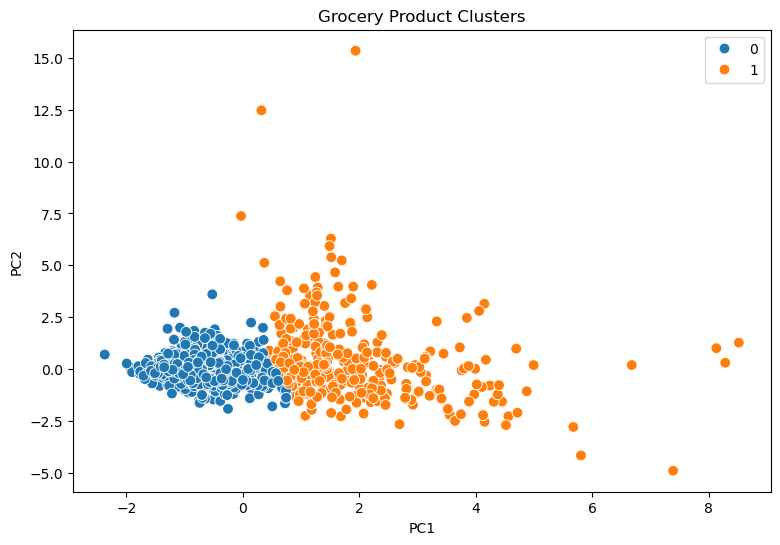

In [33]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=train_clusters,
    palette="tab10",
    s=60
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Grocery Product Clusters")

plt.show()

In [34]:
results = pd.DataFrame({
    "K": list(range(2, 11)),
    "Silhouette": silhouette_scores,
    "Inertia": inertia
})

results.round(4)

,K,Silhouette,Inertia
0,2,0.4314,7799.3106
1,3,0.4275,6624.9702
2,4,0.4012,5817.0122
3,5,0.3777,5159.5017
4,6,0.3877,4510.1895
5,7,0.2393,4158.1925
6,8,0.3865,3810.4825
7,9,0.2275,3493.0859
8,10,0.2400,3193.1974


In [35]:
results.sort_values(
    "Silhouette",
    ascending=False
)

,K,Silhouette,Inertia
0,2,0.431369,7799.310553
1,3,0.427546,6624.970197
2,4,0.401183,5817.012248
4,6,0.387681,4510.189478
6,8,0.386534,3810.482504
3,5,0.377708,5159.501691
8,10,0.239986,3193.197361
5,7,0.239299,4158.192539
7,9,0.227539,3493.085900


In [36]:
cluster_profile = (
    train_data
    .groupby("Cluster")
    .mean()
    .round(2)
)

cluster_profile

,Price_num,Discount_num,Rating_num,Reviews_num,Title_Length,Feature_Length,Description_Length
Cluster,,,,,,,
0,26.03,0.36,4.50,297.17,54.93,84.01,335.39
1,145.52,2.16,4.27,663.65,65.94,163.76,1490.67


In [37]:
cluster_counts = (
    train_data["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_counts

Cluster
0    1028
1     375
Name: count, dtype: int64

In [38]:
display(cluster_profile)
display(cluster_counts)

,Price_num,Discount_num,Rating_num,Reviews_num,Title_Length,Feature_Length,Description_Length
Cluster,,,,,,,
0,26.03,0.36,4.50,297.17,54.93,84.01,335.39
1,145.52,2.16,4.27,663.65,65.94,163.76,1490.67


Cluster
0    1028
1     375
Name: count, dtype: int64

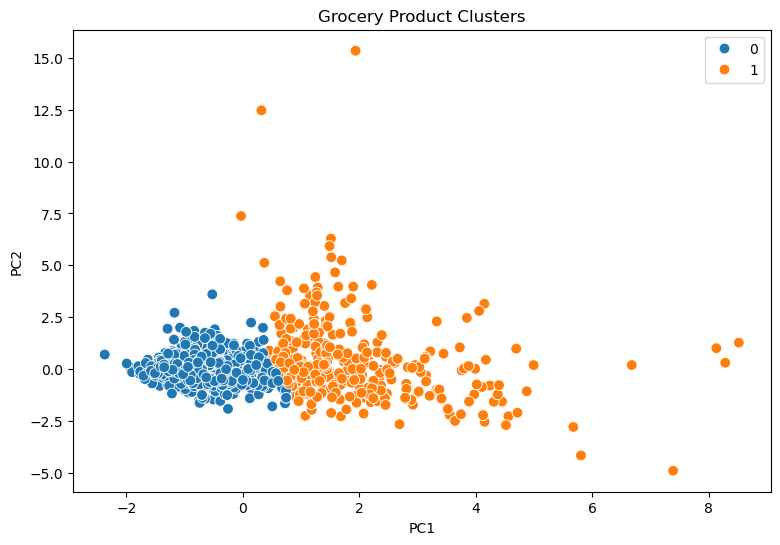

In [39]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=train_clusters,
    palette="tab10",
    s=60
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Grocery Product Clusters")

plt.show()

In [40]:
results.round(4)
cluster_profile
cluster_counts

Cluster
0    1028
1     375
Name: count, dtype: int64

In [41]:
cluster_profile = (
    train_data
    .groupby("Cluster")
    .mean()
    .round(2)
)

cluster_profile

,Price_num,Discount_num,Rating_num,Reviews_num,Title_Length,Feature_Length,Description_Length
Cluster,,,,,,,
0,26.03,0.36,4.50,297.17,54.93,84.01,335.39
1,145.52,2.16,4.27,663.65,65.94,163.76,1490.67


In [42]:
for cluster in sorted(train_products["Cluster"].unique()):
    
    print(f"\n========== CLUSTER {cluster} ==========")
    
    display(
        train_products[
            train_products["Cluster"] == cluster
        ][
            [
                "Title",
                "Sub Category",
                "Price_num",
                "Discount_num",
                "Rating_num",
                "Reviews_num"
            ]
        ].head(10)
    )


========== CLUSTER 0 ==========


,Title,Sub Category,Price_num,Discount_num,Rating_num,Reviews_num
199,"Bisquick, Pancake & Baking Mix, 96 oz",Breakfast,10.99,0.0,4.5,208.0
1376,"Eco Raj 6-inch Compostable Bagasse Plate, 1000...",Paper & Plastic Products,52.99,0.0,3.7,6.0
798,"Sharpie Fine Point Permanent Marker, 25-count",Household,16.99,0.0,4.5,208.0
1234,"Hidden Valley, Original Ranch Dressing, 40 fl ...",Pantry & Dry Goods,14.99,0.0,4.5,208.0
1576,No Sugar Keto Bar Chocolate Chip Cookie Dough ...,Snacks,42.99,0.0,3.7,82.0
1348,"Dixie Ultra 8-1/2"" Paper Plate, 240-count",Paper & Plastic Products,22.99,0.0,4.5,208.0
1280,Nielsen-Massey Madagascar Bourbon Pure Vanilla...,Pantry & Dry Goods,49.99,0.0,4.8,880.0
669,The Fruit Company Vintage Crate with Pears & A...,Gift Baskets,59.99,0.0,4.5,314.0
1108,"Authentic Wagyu Japanese A5 Ground Beef, 4 Tot...",Meat & Seafood,129.99,0.0,4.0,22.0
371,Tide Pods with Ultra Oxi HE Laundry Detergent ...,Cleaning Supplies,28.79,0.0,4.5,208.0



========== CLUSTER 1 ==========


,Title,Sub Category,Price_num,Discount_num,Rating_num,Reviews_num
609,Fleur Floral Arrangement,Floral,42.99,0.0,3.9,2622.0
310,"Starburst Chewy Candy, Original, Full Size, 2....",Candy,36.99,0.0,4.5,208.0
1121,"Seeds of Change, Organic Quinoa and Brown Rice...",Organic,14.99,0.0,4.5,208.0
107,Pulp and Press 5-Day Organic Cold Pressed Juic...,Beverages & Water,159.99,0.0,4.3,210.0
1088,"Quality Ethnic Foods Halal Goat Cubes, (5/2.2 ...",Meat & Seafood,99.99,0.0,4.2,67.0
596,Valentine's Day Cherish Forever Arrangement,Floral,59.99,0.0,4.5,208.0
1080,"Tsar Nicoulai Caviar Sturgeon Pate 6 oz, 6-pack",Meat & Seafood,59.99,0.0,4.1,114.0
701,Plaza Golden Osetra 2 oz Caviar Gift Set,Gift Baskets,169.99,0.0,4.5,268.0
917,"Kirkland Signature Dental Chews, 72-count",Kirkland Signature Grocery,36.99,0.0,4.7,5134.0
1419,"Premium Seafood Variety Pack - 20 Total Packs,...",Seafood,349.99,0.0,4.4,8.0


In [43]:
joblib.dump(
    kmeans,
    "../models/kmeans.pkl"
)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

joblib.dump(
    features,
    "../models/features.pkl"
)

print("Models saved successfully.")

Models saved successfully.


In [44]:
cluster_profile


,Price_num,Discount_num,Rating_num,Reviews_num,Title_Length,Feature_Length,Description_Length
Cluster,,,,,,,
0,26.03,0.36,4.50,297.17,54.93,84.01,335.39
1,145.52,2.16,4.27,663.65,65.94,163.76,1490.67


In [45]:
CLUSTER_NAMES = {
    0: "Budget & Discount Products",
    1: "Premium & Popular Products"
}